Total Training Samples: 34025

ERROR METRICS
MAE  : 1.8772 °C
RMSE : 2.3461 °C
R² Score : 0.999964


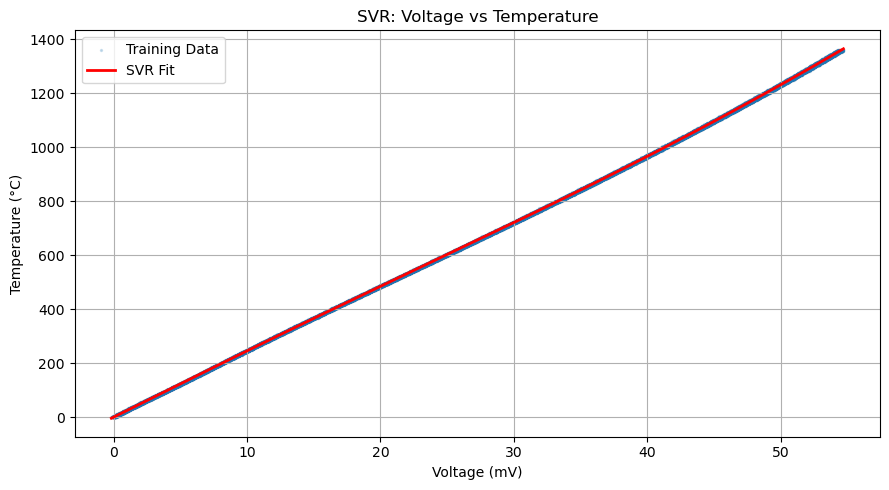

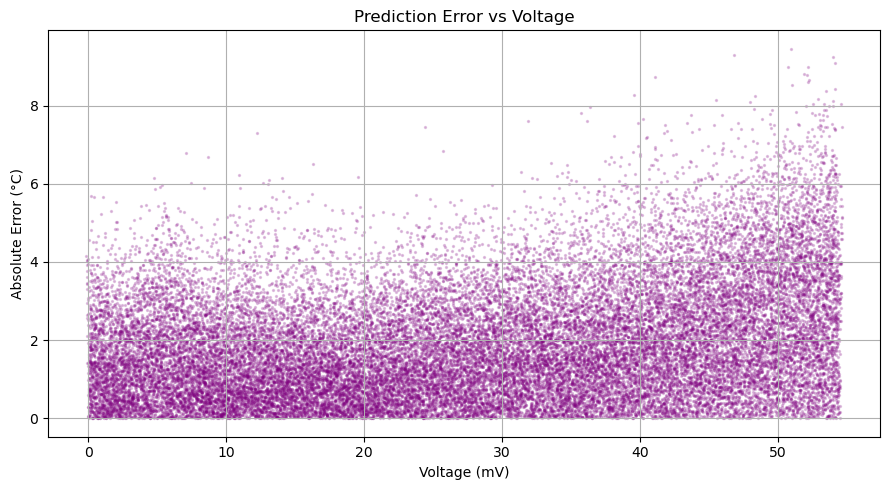


MANUAL CHECK
--------------------------------------------------
0.039 mV --> 0.85 °C
0.397 mV --> 9.65 °C
6.299 mV --> 155.08 °C
48.838 mV --> 1200.46 °C
43.518 mV --> 1057.83 °C
45.119 mV --> 1100.04 °C
5.123 mV --> 126.14 °C


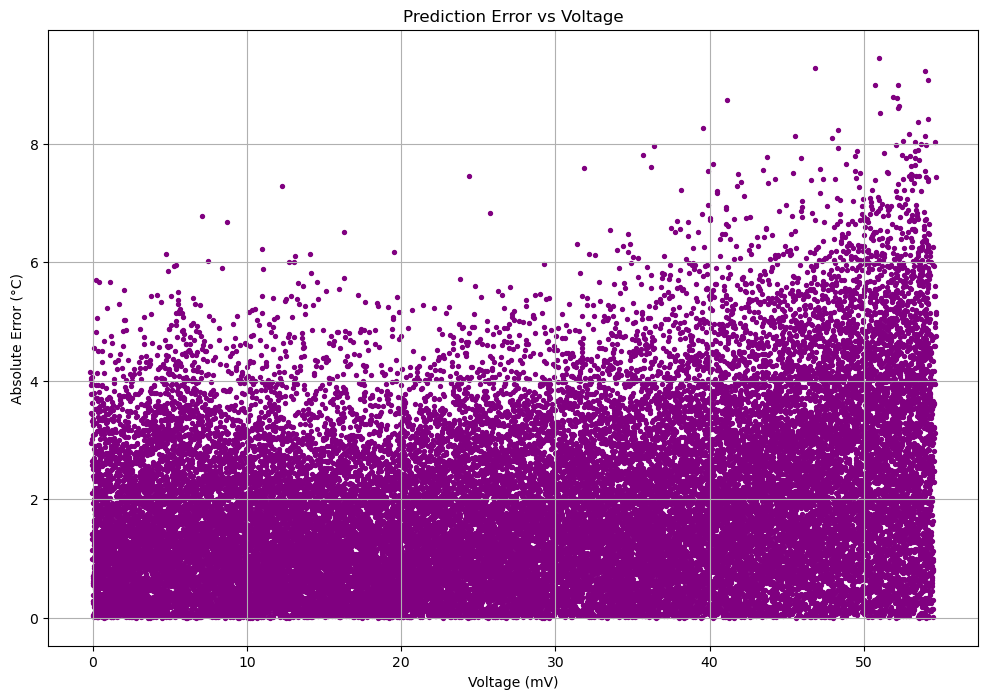

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Load Dataset
# -----------------------------
data = pd.read_csv("NIST Thermocouple Type K 2.csv")

temperature = data["Temperature"].values
ideal_voltage = data["Voltage"].values

# -----------------------------
# 2. Data Augmentation
# -----------------------------
np.random.seed(42)

N = 25  # Number of augmented copies

X_augmented = []
y_augmented = []

for i in range(N):

    gain_drift = np.random.uniform(-0.005, 0.005)      # ±0.5%
    offset_drift = np.random.uniform(-0.10, 0.10)      # ±0.1 mV
    noise = np.random.normal(0, 0.05, size=len(ideal_voltage))

    drifted = ideal_voltage * (1 + gain_drift) + offset_drift + noise

    X_augmented.append(drifted)
    y_augmented.append(temperature)

X_augmented = np.concatenate(X_augmented).reshape(-1, 1)
y_augmented = np.concatenate(y_augmented)

print("Total Training Samples:", len(X_augmented))

# -----------------------------
# 3. Scaling
# -----------------------------
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_augmented)
y_scaled = scaler_y.fit_transform(
    y_augmented.reshape(-1, 1)
).ravel()

# -----------------------------
# 4. Train SVR
# -----------------------------
model = SVR(
    kernel="rbf",
    C=1000,
    gamma=0.05,
    epsilon=0.01
)

model.fit(X_scaled, y_scaled)

# -----------------------------
# 5. Prediction
# -----------------------------
y_pred_scaled = model.predict(X_scaled)
y_pred = scaler_y.inverse_transform(
    y_pred_scaled.reshape(-1, 1)
).flatten()

# -----------------------------
# 6. Error Metrics
# -----------------------------
errors = np.abs(y_augmented - y_pred)

mae = mean_absolute_error(y_augmented, y_pred)
rmse = np.sqrt(mean_squared_error(y_augmented, y_pred))
r2 = r2_score(y_augmented, y_pred)

print("\nERROR METRICS")
print(f"MAE  : {mae:.4f} °C")
print(f"RMSE : {rmse:.4f} °C")
print(f"R² Score : {r2:.6f}")

# -----------------------------
# 7. SVR Fit Graph
# -----------------------------
sort_idx = np.argsort(X_augmented.flatten())

X_sorted = X_augmented[sort_idx]
X_sorted_scaled = scaler_X.transform(X_sorted)

y_sorted_pred_scaled = model.predict(X_sorted_scaled)
y_sorted_pred = scaler_y.inverse_transform(
    y_sorted_pred_scaled.reshape(-1, 1)
).flatten()

plt.figure(figsize=(9,5))
plt.scatter(
    X_augmented,
    y_augmented,
    s=2,
    alpha=0.2,
    label="Training Data"
)

plt.plot(
    X_sorted,
    y_sorted_pred,
    color="red",
    linewidth=2,
    label="SVR Fit"
)

plt.xlabel("Voltage (mV)")
plt.ylabel("Temperature (°C)")
plt.title("SVR: Voltage vs Temperature")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Error Graph
# -----------------------------
plt.figure(figsize=(9,5))

plt.scatter(
    X_augmented,
    errors,
    s=2,
    alpha=0.2,
    color="purple"
)

plt.xlabel("Voltage (mV)")
plt.ylabel("Absolute Error (°C)")
plt.title("Prediction Error vs Voltage")
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 9. Manual Check
# -----------------------------
print("\nMANUAL CHECK")
print("-" * 50)

manual_voltages = np.array([
    [0.039],     # ~1°C
    [0.397],     # ~10°C
    [6.299],     # ~154°C
    [48.838],    # ~1200°C
    [43.518],    # ~1058°C
    [45.119],    # ~1100°C
    [5.123]      # ~125°C 
])

actual_temps = [1, 10, 154, 1200, 1058, 1100, 125]

manual_scaled = scaler_X.transform(manual_voltages)

manual_pred_scaled = model.predict(manual_scaled)

manual_pred = scaler_y.inverse_transform(
    manual_pred_scaled.reshape(-1,1)
).flatten()

for v, t in zip(manual_voltages.flatten(), manual_pred):
    print(f"{v:.3f} mV --> {t:.2f} °C")


# -----------------------------
# 10. Error vs Voltage (Smooth Curve)
# -----------------------------
sort_idx = np.argsort(X_augmented.flatten())

plt.figure(figsize=(12,8))
plt.scatter(
    X_augmented[sort_idx],
    errors[sort_idx],
    s=8,
    color="purple"
)

plt.xlabel("Voltage (mV)")
plt.ylabel("Absolute Error (°C)")
plt.title("Prediction Error vs Voltage")
plt.grid(True)
plt.show()